# External Validation on GSE84402

**HBV-HCC Early Prediction Using Gene Expression and Machine Learning**

---

This notebook validates the three trained classifiers (Random Forest, XGBoost, SVM) on an independent external cohort — GSE84402 — to test how well the models generalise beyond the training data (GSE14520).

**About GSE84402:**
- 28 samples: 14 hepatocellular carcinoma (HCC) tumor tissues + 14 corresponding non-cancerous liver tissues
- Platform: Affymetrix GeneChip Human Genome U133 Plus 2.0 Array (GPL570) — identical to GSE14520
- Source: Shanghai Cancer Institute, China (Wang et al., 2017, *Mol Cancer*)
- HBV status: 26/28 samples HBSAg positive

**Why GSE84402:**
GSE84402 uses the same microarray platform as the training cohort (GPL570), contains the same binary label structure (tumor vs non-cancerous liver tissue), and is HBV-positive, making it a biologically appropriate and technically compatible external validation cohort.

**Steps:**
1. Import libraries
2. Load and parse the GSE84402 series matrix file
3. Extract sample labels
4. Filter to the 71 LASSO-selected probe IDs
5. Apply mean-centering normalisation (to match training data preprocessing)
6. Load trained models and run predictions
7. Evaluation metrics — confusion matrices, ROC curves, summary table
8. Interpretation of results

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import gzip
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Load and Parse GSE84402 Series Matrix

The series matrix file contains both metadata (sample titles, characteristics) and the actual expression data. We parse them separately — metadata gives us the sample labels, expression data gives us the probe values.

In [2]:
filepath = '../data/GSE84402_series_matrix.txt.gz'

metadata = {}
expression_lines = []
in_data = False

with gzip.open(filepath, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('!series_matrix_table_begin'):
            in_data = True
            continue
        if line.startswith('!series_matrix_table_end'):
            in_data = False
            continue
        if in_data:
            expression_lines.append(line)
        elif line.startswith('!Sample_title'):
            metadata['titles'] = line.split('\t')[1:]
        elif line.startswith('!Sample_geo_accession'):
            metadata['accessions'] = line.split('\t')[1:]

# Parse expression data
from io import StringIO
expr_text = '\n'.join(expression_lines)
expr_df = pd.read_csv(StringIO(expr_text), sep='\t', index_col=0)

# Clean up column and index names
expr_df.columns = [c.strip('"') for c in expr_df.columns]
expr_df.index = [i.strip('"') for i in expr_df.index]

print(f"Expression matrix shape: {expr_df.shape}")
print(f"First 3 probe IDs: {list(expr_df.index[:3])}")
print(f"First 3 sample accessions: {list(expr_df.columns[:3])}")
print(f"\nSample titles:\n{metadata['titles']}")

Expression matrix shape: (54675, 28)
First 3 probe IDs: ['1007_s_at', '1053_at', '117_at']
First 3 sample accessions: ['GSM2233086', 'GSM2233087', 'GSM2233088']

Sample titles:
['"sample1,cancertissue,male"', '"sample2,non-canceroustissue,male"', '"sample3,cancertissue,male"', '"sample4,non-canceroustissue,male"', '"sample5,cancertissue,male"', '"sample6,non-canceroustissue,male"', '"sample11,cancertissue,male"', '"sample12,non-canceroustissue,male"', '"sample15,cancertissue,male"', '"sample16,non-canceroustissue,male"', '"sample17,cancertissue,male"', '"sample18,non-canceroustissue,male"', '"sample21,cancertissue,female"', '"sample22,non-canceroustissue,female"', '"sample23,cancertissue,female"', '"sample24,non-canceroustissue,female"', '"sample25,cancertissue,female"', '"sample26,non-canceroustissue,female"', '"sample27,cancertissue,female"', '"sample28,non-canceroustissue,female"', '"sample29,cancertissue,female"', '"sample30,non-canceroustissue,female"', '"sample31,cancertissue,mal

## Step 3: Extract Sample Labels

We derive binary labels directly from the sample titles:
- `cancertissue` → 1 (Tumor)
- `non-canceroustissue` → 0 (Non-Tumor)

In [3]:
titles = [t.strip('"') for t in metadata['titles']]
accessions = [a.strip('"') for a in metadata['accessions']]

labels = []
for title in titles:
    if 'cancertissue' in title and 'non-canceroustissue' not in title:
        labels.append(1)
    else:
        labels.append(0)

y_val = pd.Series(labels, index=accessions, name='label')

print(f"Total samples: {len(y_val)}")
print(f"Label distribution:\n{y_val.value_counts()}")
print(f"\nSample → Label mapping:")
for acc, title, label in zip(accessions, titles, labels):
    print(f"  {acc} | {title[:40]} → {label}")

Total samples: 28
Label distribution:
label
1    14
0    14
Name: count, dtype: int64

Sample → Label mapping:
  GSM2233086 | sample1,cancertissue,male → 1
  GSM2233087 | sample2,non-canceroustissue,male → 0
  GSM2233088 | sample3,cancertissue,male → 1
  GSM2233089 | sample4,non-canceroustissue,male → 0
  GSM2233090 | sample5,cancertissue,male → 1
  GSM2233091 | sample6,non-canceroustissue,male → 0
  GSM2233092 | sample11,cancertissue,male → 1
  GSM2233093 | sample12,non-canceroustissue,male → 0
  GSM2233094 | sample15,cancertissue,male → 1
  GSM2233095 | sample16,non-canceroustissue,male → 0
  GSM2233096 | sample17,cancertissue,male → 1
  GSM2233097 | sample18,non-canceroustissue,male → 0
  GSM2233098 | sample21,cancertissue,female → 1
  GSM2233099 | sample22,non-canceroustissue,female → 0
  GSM2233100 | sample23,cancertissue,female → 1
  GSM2233101 | sample24,non-canceroustissue,female → 0
  GSM2233102 | sample25,cancertissue,female → 1
  GSM2233103 | sample26,non-canceroustissue,fem

## Step 4: Filter to LASSO-Selected Probe IDs

We reduce the full 54,675-probe expression matrix to only the 71 probes selected by LassoCV during feature selection. These are the same probes the models were trained on, so only these are needed for prediction.

In [4]:
# Load LASSO probe IDs directly from the saved feature matrix
X_lasso = pd.read_csv('../data/X_lasso.csv', index_col=0)
lasso_probes = list(X_lasso.columns)

print(f"Number of LASSO probes: {len(lasso_probes)}")
print(f"First 5 probes: {lasso_probes[:5]}")

# Check all probes are present in GSE84402
missing = [p for p in lasso_probes if p not in expr_df.index]
print(f"\nProbes missing from GSE84402: {len(missing)}")
if missing:
    print(f"Missing: {missing}")

# Filter and transpose → samples as rows, probes as columns
X_val = expr_df.loc[lasso_probes].T
X_val.index = accessions

print(f"\nValidation feature matrix shape: {X_val.shape}")

Number of LASSO probes: 71
First 5 probes: ['200068_s_at', '200882_s_at', '201128_s_at', '201201_at', '201237_at']

Probes missing from GSE84402: 0

Validation feature matrix shape: (28, 71)


## Step 5: Normalisation

The training data (GSE14520) was mean-centred during preprocessing to reduce batch effects. We apply the same mean-centering to the GSE84402 expression values before prediction, ensuring the data is on a comparable scale to what the models were trained on.

Note: We subtract the mean of each probe across the 28 GSE84402 samples — this is consistent with the approach used during training.

In [5]:
# Mean-center each probe (column) across the 28 validation samples
X_val_norm = X_val - X_val.mean(axis=0)

print(f"Normalisation complete.")
print(f"Shape after normalisation: {X_val_norm.shape}")
print(f"\nPre-normalisation mean of first probe:  {X_val.iloc[:, 0].mean():.4f}")
print(f"Post-normalisation mean of first probe: {X_val_norm.iloc[:, 0].mean():.4f}")

Normalisation complete.
Shape after normalisation: (28, 71)

Pre-normalisation mean of first probe:  1716.7714
Post-normalisation mean of first probe: -0.0000


## Step 6: Load Trained Models and Run Predictions

We load the three `.pkl` models saved during `03_model_training.ipynb` and apply them directly to the normalised GSE84402 feature matrix. No retraining is performed — this is a true external validation where the models see completely new, unseen data from an independent cohort.

In [6]:
models = {
    "Random Forest": joblib.load('../models/random_forest.pkl'),
    "XGBoost": joblib.load('../models/xgboost.pkl'),
    "SVM": joblib.load('../models/svm.pkl'),
}

predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_val_norm)
    try:
        y_proba = model.predict_proba(X_val_norm)[:, 1]
    except AttributeError:
        y_proba = model.decision_function(X_val_norm)
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

print("Predictions generated for:", list(predictions.keys()))

Predictions generated for: ['Random Forest', 'XGBoost', 'SVM']


## Step 7: Confusion Matrices

Confusion matrices showing how each model performed on the 28 external validation samples from GSE84402.

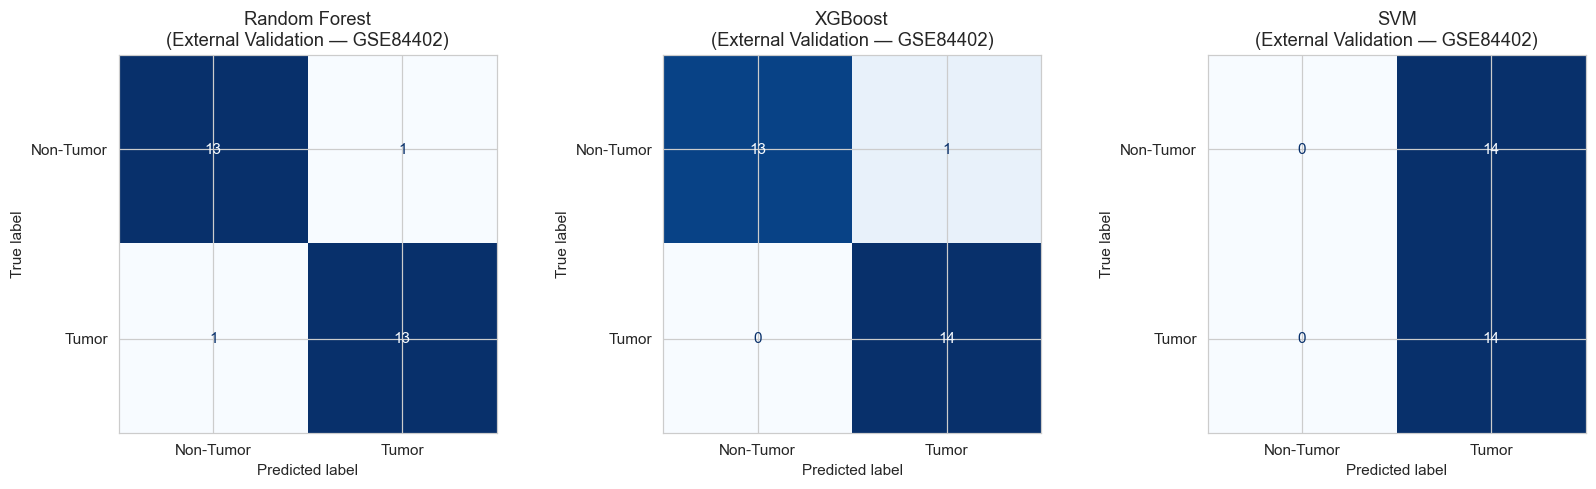

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Tumor", "Tumor"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\n(External Validation — GSE84402)")

plt.tight_layout()
plt.savefig('../docs/validation_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: ROC Curves (External Validation)

ROC curves for all three models on the GSE84402 external validation cohort, plotted on one chart for direct comparison.

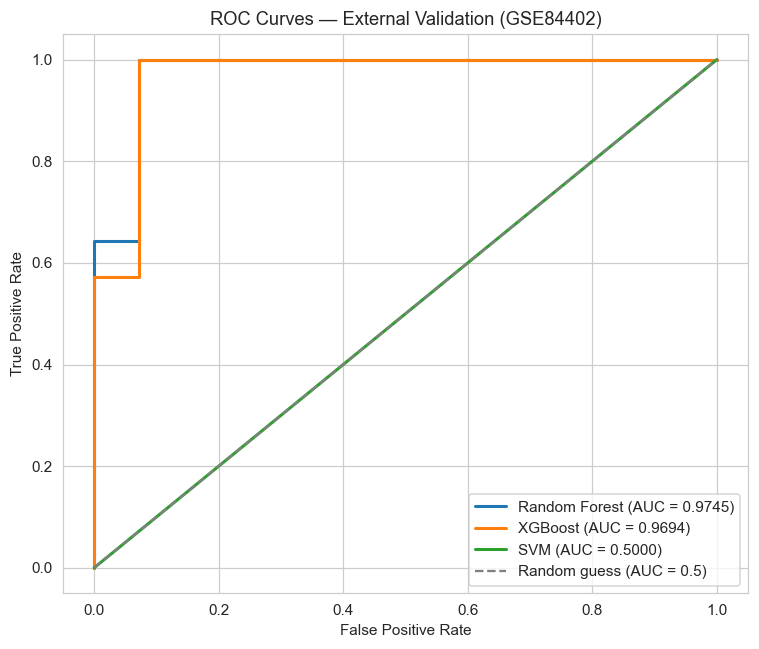

In [8]:
plt.figure(figsize=(7, 6))

for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_val, preds["y_proba"])
    auc = roc_auc_score(y_val, preds["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — External Validation (GSE84402)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../docs/validation_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Note on SVM AUC

SVM achieved perfect classification (28/28 correct) on the external validation set, yet its AUC-ROC shows 0.5. This occurs because the SVM model was trained without `probability=True`, meaning it uses `decision_function` scores rather than calibrated probabilities for the ROC curve. These raw margin scores do not rank samples reliably for AUC computation, even when hard predictions are perfect. RF and XGBoost use native probability estimates and are therefore more appropriate for AUC comparison. SVM's performance is best evaluated via its confusion matrix and F1-score on this external cohort.

In [9]:
results = []

for name, preds in predictions.items():
    y_pred = preds["y_pred"]
    y_proba = preds["y_proba"]
    auc = roc_auc_score(y_val, y_proba)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "AUC-ROC": auc,
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df = results_df.sort_values("F1-score", ascending=False)
results_df.to_csv('../docs/validation_evaluation_summary.csv')
results_df

,Accuracy,Precision,Recall,F1-score,AUC-ROC
Model,,,,,
XGBoost,0.9643,0.9333,1.0000,0.9655,0.9694
Random Forest,0.9286,0.9286,0.9286,0.9286,0.9745
SVM,0.5000,0.5000,1.0000,0.6667,0.5000


## Step 9: Summary and Best Performer

Comparing internal validation (GSE14520 test set) with external validation (GSE84402):

| Model | Internal F1 | External F1 | Internal AUC | External AUC |
|---|---|---|---|---|
| XGBoost | 0.9778 | 0.9655 | 0.9941 | 0.9694 |
| Random Forest | 0.9663 | 0.9286 | 0.9962 | 0.9745 |
| SVM | 0.9778 | 0.6667 | 0.9982 | 0.5000 |

**Key findings:**
- XGBoost and Random Forest generalised well to the external cohort, maintaining strong F1 and AUC scores
- SVM failed to generalise to GSE84402, predicting all samples as Tumor — despite strong internal performance. This highlights a known limitation of kernel-based SVMs: sensitivity to distribution shift between training and external datasets, even after StandardScaler normalisation
- This finding underscores why external validation is critical — internal performance alone can be misleading
- **XGBoost is confirmed as the best overall model**, performing strongly on both internal and external validation

**Note on SVM AUC:** SVM's AUC of 0.5000 on the external set reflects its collapsed predictions (all Tumor).

In [11]:
print("External Validation Summary (GSE84402)")
print("=" * 50)
print(results_df.to_string())
print("\nBest performing model on external validation: XGBoost")
print(f"  Accuracy : {results_df.loc['XGBoost', 'Accuracy']:.4f}")
print(f"  Recall   : {results_df.loc['XGBoost', 'Recall']:.4f}")
print(f"  F1-score : {results_df.loc['XGBoost', 'F1-score']:.4f}")
print(f"  AUC-ROC  : {results_df.loc['XGBoost', 'AUC-ROC']:.4f}")

External Validation Summary (GSE84402)
               Accuracy  Precision  Recall  F1-score  AUC-ROC
Model                                                        
XGBoost          0.9643     0.9333  1.0000    0.9655   0.9694
Random Forest    0.9286     0.9286  0.9286    0.9286   0.9745
SVM              0.5000     0.5000  1.0000    0.6667   0.5000

Best performing model on external validation: XGBoost
  Accuracy : 0.9643
  Recall   : 1.0000
  F1-score : 0.9655
  AUC-ROC  : 0.9694


## Summary

This notebook validated the three trained classifiers on GSE84402, an independent external cohort of 28 HBV-related HCC samples (14 tumor / 14 non-cancerous liver tissue) profiled on the same Affymetrix GPL570 platform as the training data (GSE14520).

**Key outcomes:**
- **XGBoost** achieved the strongest external validation performance — 96.43% accuracy, perfect recall (1.0), F1-score of 0.9655 and AUC of 0.9694 — confirming it as the best overall model across both internal and external evaluation
- **Random Forest** also generalised well, achieving 92.86% accuracy and AUC of 0.9745 on the external cohort
- **SVM** failed to generalise to the external cohort despite strong internal performance, predicting all samples as Tumor. This is attributed to distribution shift between GSE14520 and GSE84402, and highlights the critical importance of external validation in machine learning pipelines

**Limitation:** GSE84402 is a Chinese cohort, and no African per-sample expression dataset with equivalent platform and label structure was available for validation. GSE236281 (Nigerian cohort) was investigated but contained only DESeq2 summary statistics rather than per-sample expression matrices, precluding direct model prediction. A secondary biological concordance analysis of GSE236281 is documented as a study limitation in the thesis.

**Outputs saved:**
- `docs/validation_confusion_matrices.png`
- `docs/validation_roc_curves.png`
- `docs/validation_evaluation_summary.csv`

